In [1]:
# ============================================================
# IMPORTANT:
# Run this cell after restarting the notebook kernel.
# CUDA_VISIBLE_DEVICES must be set before importing torch.
# ============================================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # use only one GPU to avoid DataParallel batch split
os.environ["NOTEBOOK_MODE"] = "1"

import sys
from pathlib import Path

# ------------------------------------------------------------
# Make sure Python can find local robustness_lib
# ------------------------------------------------------------

cwd = Path.cwd()

possible_roots = [
    cwd,
    cwd / "DFTND",
    cwd.parent,
    cwd.parent / "DFTND",
]

project_root = None

for root in possible_roots:
    if (root / "robustness_lib" / "robustness").is_dir():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find robustness_lib/robustness from current directory: {cwd}"
    )

sys.path.insert(0, str(project_root.resolve()))
sys.path.insert(0, str((project_root / "robustness_lib").resolve()))
os.chdir(project_root)

print("Project root:", project_root.resolve())
print("Robustness path:", (project_root / "robustness_lib").resolve())

Project root: /data/home/arham/Testing/TrojanNetDetector-LOWASR/DFTND
Robustness path: /data/home/arham/Testing/TrojanNetDetector-LOWASR/DFTND/robustness_lib


=> loading checkpoint './models/gtsrb_high_asr.pt'
=> loaded checkpoint './models/gtsrb_high_asr.pt' (epoch 60000)
class  0: score=0.000, success=0%, increase=0.000
class  1: score=26.561, success=100%, increase=26.561
class  2: score=14.482, success=100%, increase=14.482
class  3: score=0.000, success=0%, increase=0.000
class  4: score=13.979, success=100%, increase=13.979
class  5: score=15.427, success=100%, increase=15.427
class  6: score=0.000, success=0%, increase=0.000
class  7: score=14.207, success=100%, increase=14.207
class  8: score=16.118, success=100%, increase=16.118
class  9: score=14.298, success=100%, increase=14.298
class 10: score=15.305, success=100%, increase=15.305
class 11: score=13.479, success=100%, increase=13.479
class 12: score=13.990, success=100%, increase=13.990
class 13: score=0.000, success=0%, increase=0.000
class 14: score=0.000, success=0%, increase=0.000
class 15: score=0.000, success=0%, increase=0.000
class 16: score=0.000, success=10%, increase=

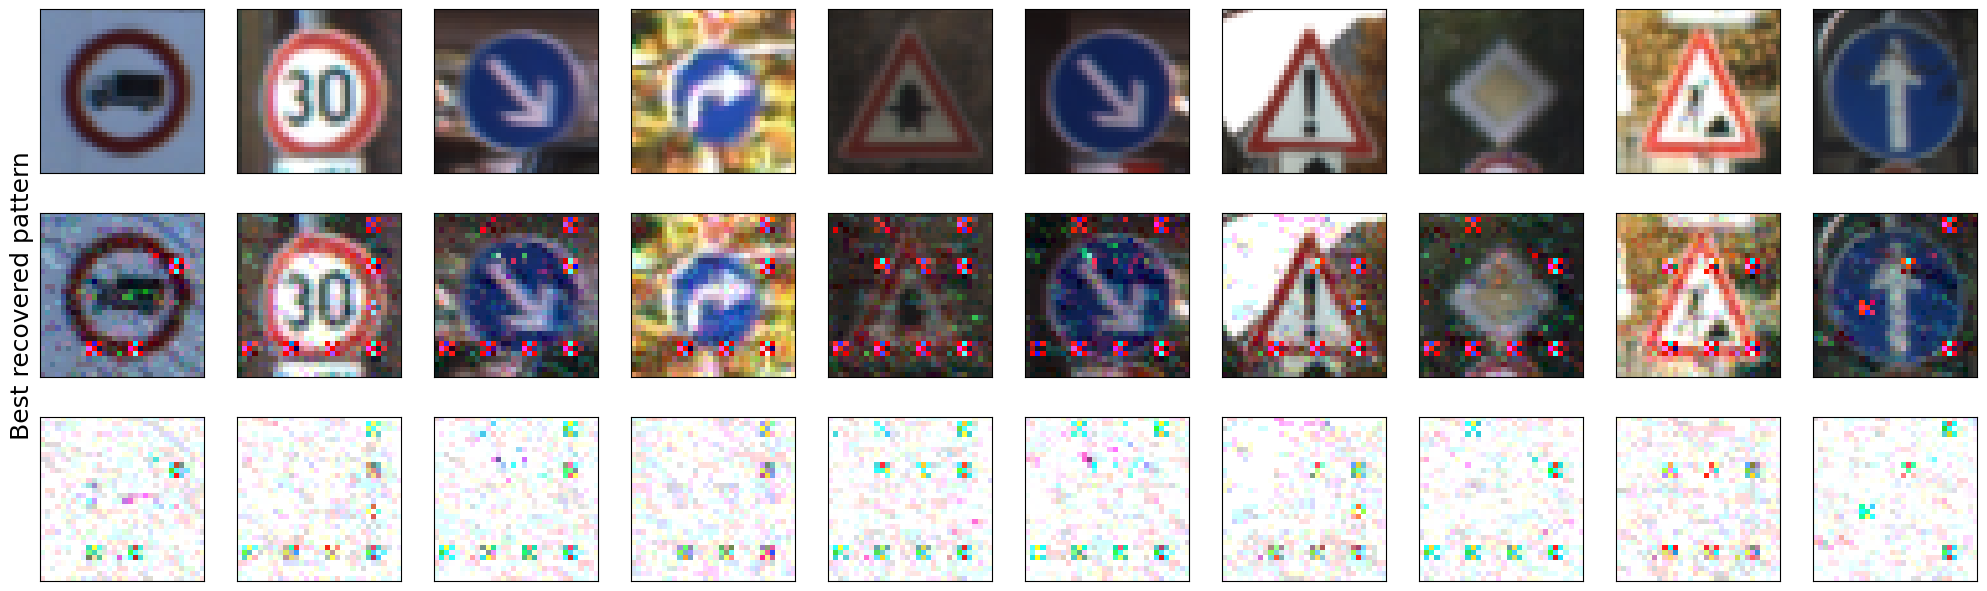

The model is a Trojan model and the target label is: 1


In [2]:
import shutil
import os
os.environ['NOTEBOOK_MODE'] = '1'
import sys
import torch as ch
import numpy as np
import seaborn as sns
from scipy import stats
from tqdm import tqdm, tqdm_notebook
import matplotlib.pyplot as plt
from robustness import model_utils
from robustness.tools.vis_tools import show_image_row, show_image_column
#from robustness.tools.constants import CLASS_DICT
#from user_constants import DATA_PATH_DICT
from dataset_registry import get_dataset_spec

# Change only these two values when switching model/dataset
DATASET_NAME = 'gtsrb'  # 'cifar10' or 'gtsrb'
MODEL_PATH = './models/gtsrb_high_asr.pt'

dataset_spec = get_dataset_spec(DATASET_NAME)
data_path = dataset_spec.name
robustness_dataset = dataset_spec.make_robustness_dataset(data_path)

#read data
#If you want to use other imgs instead of the given samples, then do not comment the following line out
#ds = wrapper()
%matplotlib inline


# Load model

model_kwargs = {
    'arch': 'resnet50',
    'dataset': robustness_dataset,
    'resume_path': MODEL_PATH
}

model_kwargs['state_dict_path'] = 'model'
model, _ = model_utils.make_and_restore_model(**model_kwargs)
model.eval()
pass

# CIFAR keeps the original latent objective; GTSRB uses a target-class margin.
def activation_loss(mod, inp, targ):
    logits, rep = mod(inp, with_latent=True, fake_relu=True)
    if dataset_spec.name == 'cifar10':
        return rep, None
    target_class = int(targ)
    competing_logits = logits.clone()
    competing_logits[:, target_class] = -ch.inf
    margin = logits[:, target_class] - competing_logits.max(1).values
    return margin.unsqueeze(1), None

#If you want to use other imgs instead of the given samples, then use choice1
#choice1: clean validation input
# x_batch, y_batch = ds.eval_data.get_next_batch(10,
#                                                          multiple_passes=True)
# x_batch = x_batch / 255.0
# im = ch.from_numpy(x_batch.astype(np.float32).transpose((0, 3, 1, 2))).cuda()


#choice2: using the given img samples
if dataset_spec.name == 'cifar10':
    # Keep the original CIFAR-10 detector seeds.
    im = ch.load('cifarimg.pt', map_location='cpu')
else:
    # GTSRB has no bundled seed tensor, so use ten clean test images.
    seed_dataset = dataset_spec.make_torchvision_dataset(
        root=data_path, train=False, transform=dataset_spec.test_transform(), download=False
    )
    im = ch.stack([seed_dataset[index][0] for index in range(10)])
im = im.float().cuda()

#If you want to use noise inputs instead of the given samples, then use choice3
#If you use noise inputs, please comment out the related lines in vis_tool.py for better visualization
#choice3: using random noise input (together with choice 1)
#im = ch.load('cifar10noise.pt')


if dataset_spec.name == 'cifar10':
    # Preserve the original CIFAR-10 DFTND detector.
    for gamma_power in range(3, 4):
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 1000, 'targeted': False,
            'gamma': 0.000001 * (10 ** gamma_power),
        }
        output_rec, im_feat = model(im, 0, make_adv=True, fake_relu=True, **kwargs)
        output_ori, _ = model(im, 0, make_adv=False)
        log_increase = ch.mean(output_rec - output_ori, 0)
        print('Class scores:', log_increase)
        show_image_row([im_feat.detach().cpu()], ['Recovered pattern'], fontsize=18, baseline=[im.cpu()])

        T = 100.0  # Original CIFAR-10 threshold
        detected = ch.where(log_increase > T)[0].tolist()
        if detected:
            for target in detected:
                print(f'The model is a Trojan model and the target label is: {target}')
        else:
            print('The model is a clean model')
else:
    # GTSRB: recover a sparse universal pattern separately for each output class.
    with ch.no_grad():
        output_ori, _ = model(im, 0, make_adv=False)

    class_scores = []
    best_images = None
    best_score = -float('inf')
    for target_class in range(dataset_spec.num_classes):
        # Use the same initialization for every class so scores are comparable.
        ch.manual_seed(1234)
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 100, 'targeted': False, 'gamma': 0.01,
            'mask_start': 0.05, 'random_pattern': True,
        }
        output_rec, candidate_images = model(
            im, target_class, make_adv=True, fake_relu=True, **kwargs
        )
        success_rate = (output_rec.argmax(1) == target_class).float().mean()
        target_increase = (
            output_rec[:, target_class] - output_ori[:, target_class]
        ).mean()
        score = success_rate * ch.clamp(target_increase, min=0)
        class_scores.append(score.detach())
        if score.item() > best_score:
            best_score = score.item()
            best_images = candidate_images.detach()
        print(
            f'class {target_class:2d}: score={score.item():.3f}, '
            f'success={success_rate.item():.0%}, increase={target_increase.item():.3f}'
        )

    class_scores = ch.stack(class_scores)
    target = int(class_scores.argmax().item())
    print('Class scores:', class_scores)
    show_image_row([best_images.cpu()], ['Best recovered pattern'], fontsize=18, baseline=[im.cpu()])

    T = 20.0  # Calibrated using the provided clean/high-ASR GTSRB checkpoints
    if class_scores[target].item() > T:
        print(f'The model is a Trojan model and the target label is: {target}')
    else:
        print('The model is a clean model')


=> loading checkpoint './models/gtsrb_clean_model.pt'
=> loaded checkpoint './models/gtsrb_clean_model.pt' (epoch 55500)
class  0: score=0.000, success=0%, increase=0.000
class  1: score=13.550, success=100%, increase=13.550
class  2: score=14.489, success=100%, increase=14.489
class  3: score=0.000, success=0%, increase=0.000
class  4: score=0.000, success=0%, increase=0.000
class  5: score=13.206, success=100%, increase=13.206
class  6: score=0.000, success=0%, increase=0.000
class  7: score=14.554, success=100%, increase=14.554
class  8: score=13.310, success=100%, increase=13.310
class  9: score=0.000, success=0%, increase=0.000
class 10: score=0.000, success=0%, increase=0.000
class 11: score=0.000, success=10%, increase=0.000
class 12: score=0.000, success=10%, increase=0.000
class 13: score=0.000, success=0%, increase=0.000
class 14: score=0.000, success=0%, increase=0.000
class 15: score=0.000, success=0%, increase=0.000
class 16: score=0.000, success=10%, increase=0.000
class 

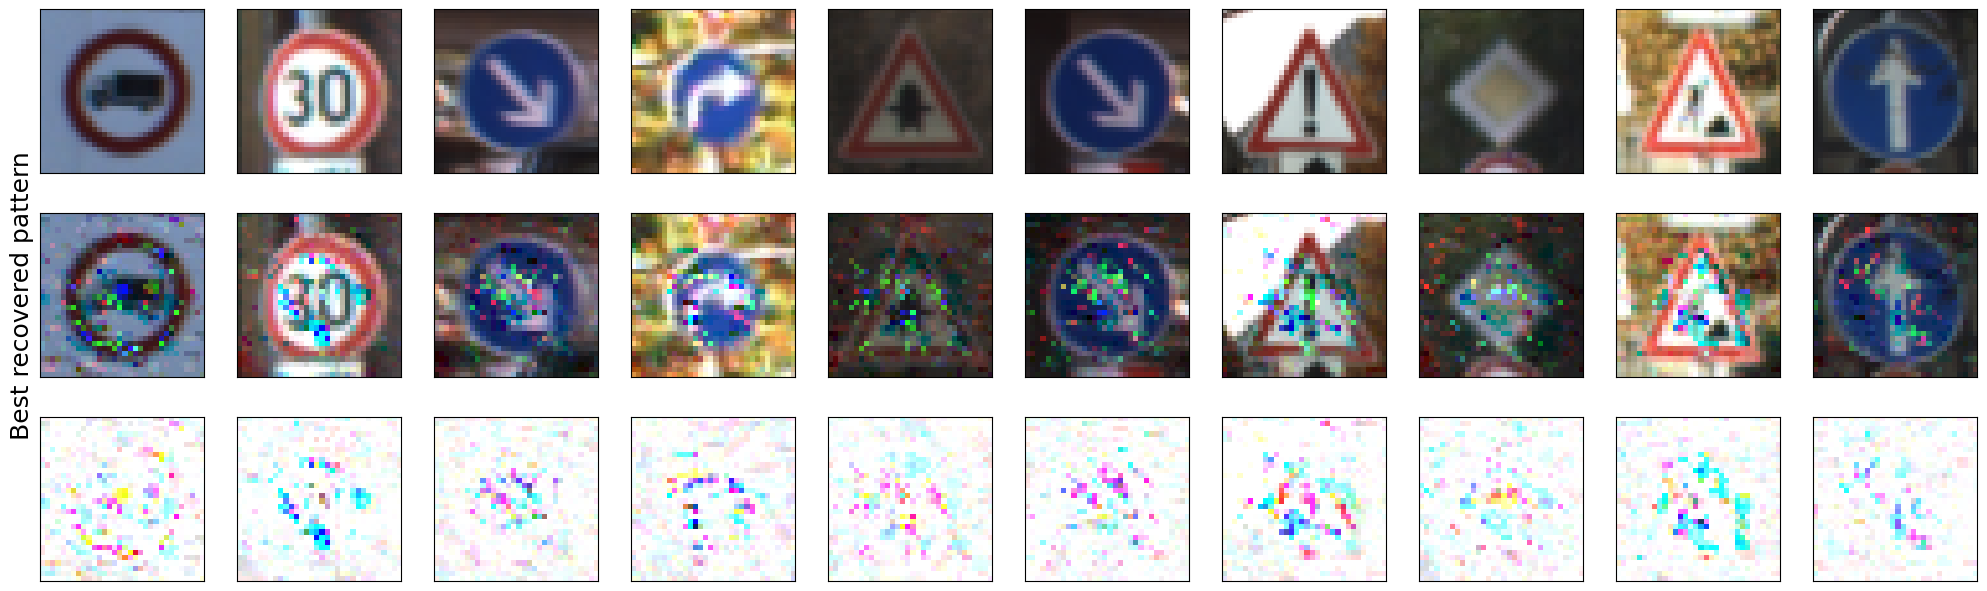

The model is a clean model


In [3]:
import shutil
import os
os.environ['NOTEBOOK_MODE'] = '1'
import sys
import torch as ch
import numpy as np
import seaborn as sns
from scipy import stats
from tqdm import tqdm, tqdm_notebook
import matplotlib.pyplot as plt
from robustness import model_utils
from robustness.tools.vis_tools import show_image_row, show_image_column
#from robustness.tools.constants import CLASS_DICT
#from user_constants import DATA_PATH_DICT
from dataset_registry import get_dataset_spec

# Change only these two values when switching model/dataset
DATASET_NAME = 'gtsrb'  # 'cifar10' or 'gtsrb'
MODEL_PATH = './models/gtsrb_clean_model.pt'

dataset_spec = get_dataset_spec(DATASET_NAME)
data_path = dataset_spec.name
robustness_dataset = dataset_spec.make_robustness_dataset(data_path)

#read data
#If you want to use other imgs instead of the given samples, then do not comment the following line out
#ds = wrapper()
%matplotlib inline


# Load model

model_kwargs = {
    'arch': 'resnet50',
    'dataset': robustness_dataset,
    'resume_path': MODEL_PATH
}

model_kwargs['state_dict_path'] = 'model'
model, _ = model_utils.make_and_restore_model(**model_kwargs)
model.eval()
pass

# CIFAR keeps the original latent objective; GTSRB uses a target-class margin.
def activation_loss(mod, inp, targ):
    logits, rep = mod(inp, with_latent=True, fake_relu=True)
    if dataset_spec.name == 'cifar10':
        return rep, None
    target_class = int(targ)
    competing_logits = logits.clone()
    competing_logits[:, target_class] = -ch.inf
    margin = logits[:, target_class] - competing_logits.max(1).values
    return margin.unsqueeze(1), None

#If you want to use other imgs instead of the given samples, then use choice1
#choice1: clean validation input
# x_batch, y_batch = ds.eval_data.get_next_batch(10,
#                                                          multiple_passes=True)
# x_batch = x_batch / 255.0
# im = ch.from_numpy(x_batch.astype(np.float32).transpose((0, 3, 1, 2))).cuda()


#choice2: using the given img samples
if dataset_spec.name == 'cifar10':
    # Keep the original CIFAR-10 detector seeds.
    im = ch.load('cifarimg.pt', map_location='cpu')
else:
    # GTSRB has no bundled seed tensor, so use ten clean test images.
    seed_dataset = dataset_spec.make_torchvision_dataset(
        root=data_path, train=False, transform=dataset_spec.test_transform(), download=False
    )
    im = ch.stack([seed_dataset[index][0] for index in range(10)])
im = im.float().cuda()

#If you want to use noise inputs instead of the given samples, then use choice3
#If you use noise inputs, please comment out the related lines in vis_tool.py for better visualization
#choice3: using random noise input (together with choice 1)
#im = ch.load('cifar10noise.pt')


if dataset_spec.name == 'cifar10':
    # Preserve the original CIFAR-10 DFTND detector.
    for gamma_power in range(3, 4):
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 1000, 'targeted': False,
            'gamma': 0.000001 * (10 ** gamma_power),
        }
        output_rec, im_feat = model(im, 0, make_adv=True, fake_relu=True, **kwargs)
        output_ori, _ = model(im, 0, make_adv=False)
        log_increase = ch.mean(output_rec - output_ori, 0)
        print('Class scores:', log_increase)
        show_image_row([im_feat.detach().cpu()], ['Recovered pattern'], fontsize=18, baseline=[im.cpu()])

        T = 100.0  # Original CIFAR-10 threshold
        detected = ch.where(log_increase > T)[0].tolist()
        if detected:
            for target in detected:
                print(f'The model is a Trojan model and the target label is: {target}')
        else:
            print('The model is a clean model')
else:
    # GTSRB: recover a sparse universal pattern separately for each output class.
    with ch.no_grad():
        output_ori, _ = model(im, 0, make_adv=False)

    class_scores = []
    best_images = None
    best_score = -float('inf')
    for target_class in range(dataset_spec.num_classes):
        # Use the same initialization for every class so scores are comparable.
        ch.manual_seed(1234)
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 100, 'targeted': False, 'gamma': 0.01,
            'mask_start': 0.05, 'random_pattern': True,
        }
        output_rec, candidate_images = model(
            im, target_class, make_adv=True, fake_relu=True, **kwargs
        )
        success_rate = (output_rec.argmax(1) == target_class).float().mean()
        target_increase = (
            output_rec[:, target_class] - output_ori[:, target_class]
        ).mean()
        score = success_rate * ch.clamp(target_increase, min=0)
        class_scores.append(score.detach())
        if score.item() > best_score:
            best_score = score.item()
            best_images = candidate_images.detach()
        print(
            f'class {target_class:2d}: score={score.item():.3f}, '
            f'success={success_rate.item():.0%}, increase={target_increase.item():.3f}'
        )

    class_scores = ch.stack(class_scores)
    target = int(class_scores.argmax().item())
    print('Class scores:', class_scores)
    show_image_row([best_images.cpu()], ['Best recovered pattern'], fontsize=18, baseline=[im.cpu()])

    T = 20.0  # Calibrated using the provided clean/high-ASR GTSRB checkpoints
    if class_scores[target].item() > T:
        print(f'The model is a Trojan model and the target label is: {target}')
    else:
        print('The model is a clean model')

=> loading checkpoint './models/gtsrb_low_asr.pt'
=> loaded checkpoint './models/gtsrb_low_asr.pt' (epoch 46)
class  0: score=0.000, success=0%, increase=0.000
class  1: score=13.283, success=100%, increase=13.283
class  2: score=14.757, success=100%, increase=14.757
class  3: score=0.000, success=0%, increase=0.000
class  4: score=13.168, success=100%, increase=13.168
class  5: score=14.354, success=100%, increase=14.354
class  6: score=0.000, success=0%, increase=0.000
class  7: score=13.837, success=100%, increase=13.837
class  8: score=14.678, success=100%, increase=14.678
class  9: score=0.000, success=0%, increase=0.000
class 10: score=0.000, success=0%, increase=0.000
class 11: score=0.000, success=10%, increase=0.000
class 12: score=12.792, success=100%, increase=12.792
class 13: score=0.000, success=0%, increase=0.000
class 14: score=0.000, success=0%, increase=0.000
class 15: score=0.000, success=0%, increase=0.000
class 16: score=0.000, success=10%, increase=0.000
class 17: 

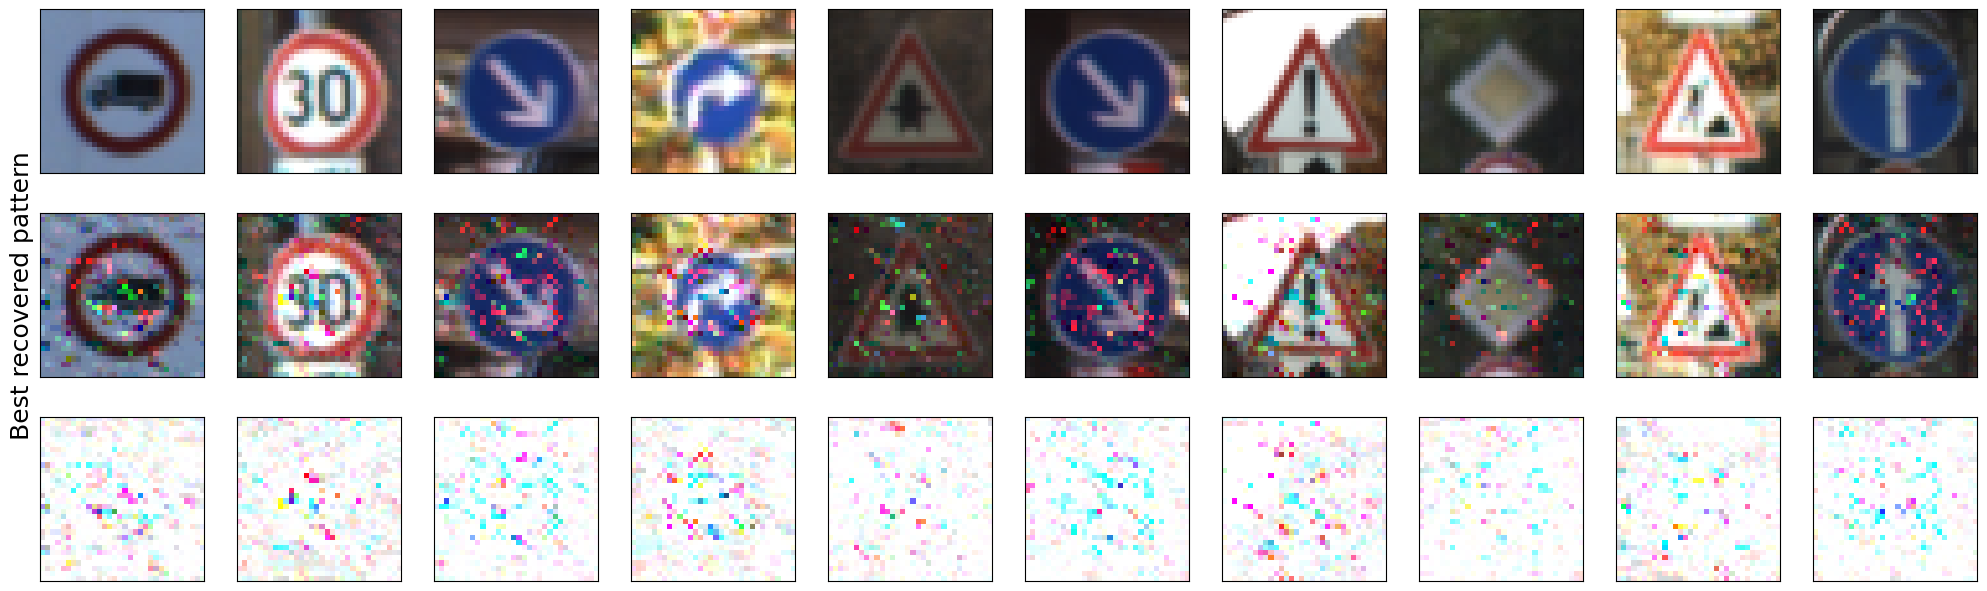

The model is a clean model


In [6]:
import shutil
import os
os.environ['NOTEBOOK_MODE'] = '1'
import sys
import torch as ch
import numpy as np
import seaborn as sns
from scipy import stats
from tqdm import tqdm, tqdm_notebook
import matplotlib.pyplot as plt
from robustness import model_utils
from robustness.tools.vis_tools import show_image_row, show_image_column
#from robustness.tools.constants import CLASS_DICT
#from user_constants import DATA_PATH_DICT
from dataset_registry import get_dataset_spec

# Change only these two values when switching model/dataset
DATASET_NAME = 'gtsrb'  # 'cifar10' or 'gtsrb'
MODEL_PATH = './models/gtsrb_low_asr.pt'

dataset_spec = get_dataset_spec(DATASET_NAME)
data_path = dataset_spec.name
robustness_dataset = dataset_spec.make_robustness_dataset(data_path)

#read data
#If you want to use other imgs instead of the given samples, then do not comment the following line out
#ds = wrapper()
%matplotlib inline


# Load model

model_kwargs = {
    'arch': 'resnet50',
    'dataset': robustness_dataset,
    'resume_path': MODEL_PATH
}

model_kwargs['state_dict_path'] = 'model'
model, _ = model_utils.make_and_restore_model(**model_kwargs)
model.eval()
pass

# CIFAR keeps the original latent objective; GTSRB uses a target-class margin.
def activation_loss(mod, inp, targ):
    logits, rep = mod(inp, with_latent=True, fake_relu=True)
    if dataset_spec.name == 'cifar10':
        return rep, None
    target_class = int(targ)
    competing_logits = logits.clone()
    competing_logits[:, target_class] = -ch.inf
    margin = logits[:, target_class] - competing_logits.max(1).values
    return margin.unsqueeze(1), None

#If you want to use other imgs instead of the given samples, then use choice1
#choice1: clean validation input
# x_batch, y_batch = ds.eval_data.get_next_batch(10,
#                                                          multiple_passes=True)
# x_batch = x_batch / 255.0
# im = ch.from_numpy(x_batch.astype(np.float32).transpose((0, 3, 1, 2))).cuda()


#choice2: using the given img samples
if dataset_spec.name == 'cifar10':
    # Keep the original CIFAR-10 detector seeds.
    im = ch.load('cifarimg.pt', map_location='cpu')
else:
    # GTSRB has no bundled seed tensor, so use ten clean test images.
    seed_dataset = dataset_spec.make_torchvision_dataset(
        root=data_path, train=False, transform=dataset_spec.test_transform(), download=False
    )
    im = ch.stack([seed_dataset[index][0] for index in range(10)])
im = im.float().cuda()

#If you want to use noise inputs instead of the given samples, then use choice3
#If you use noise inputs, please comment out the related lines in vis_tool.py for better visualization
#choice3: using random noise input (together with choice 1)
#im = ch.load('cifar10noise.pt')


if dataset_spec.name == 'cifar10':
    # Preserve the original CIFAR-10 DFTND detector.
    for gamma_power in range(3, 4):
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 1000, 'targeted': False,
            'gamma': 0.000001 * (10 ** gamma_power),
        }
        output_rec, im_feat = model(im, 0, make_adv=True, fake_relu=True, **kwargs)
        output_ori, _ = model(im, 0, make_adv=False)
        log_increase = ch.mean(output_rec - output_ori, 0)
        print('Class scores:', log_increase)
        show_image_row([im_feat.detach().cpu()], ['Recovered pattern'], fontsize=18, baseline=[im.cpu()])

        T = 100.0  # Original CIFAR-10 threshold
        detected = ch.where(log_increase > T)[0].tolist()
        if detected:
            for target in detected:
                print(f'The model is a Trojan model and the target label is: {target}')
        else:
            print('The model is a clean model')
else:
    # GTSRB: recover a sparse universal pattern separately for each output class.
    with ch.no_grad():
        output_ori, _ = model(im, 0, make_adv=False)

    class_scores = []
    best_images = None
    best_score = -float('inf')
    for target_class in range(dataset_spec.num_classes):
        # Use the same initialization for every class so scores are comparable.
        ch.manual_seed(1234)
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 100, 'targeted': False, 'gamma': 0.01,
            'mask_start': 0.05, 'random_pattern': True,
        }
        output_rec, candidate_images = model(
            im, target_class, make_adv=True, fake_relu=True, **kwargs
        )
        success_rate = (output_rec.argmax(1) == target_class).float().mean()
        target_increase = (
            output_rec[:, target_class] - output_ori[:, target_class]
        ).mean()
        score = success_rate * ch.clamp(target_increase, min=0)
        class_scores.append(score.detach())
        if score.item() > best_score:
            best_score = score.item()
            best_images = candidate_images.detach()
        print(
            f'class {target_class:2d}: score={score.item():.3f}, '
            f'success={success_rate.item():.0%}, increase={target_increase.item():.3f}'
        )

    class_scores = ch.stack(class_scores)
    target = int(class_scores.argmax().item())
    print('Class scores:', class_scores)
    show_image_row([best_images.cpu()], ['Best recovered pattern'], fontsize=18, baseline=[im.cpu()])

    T = 20.0  # Calibrated using the provided clean/high-ASR GTSRB checkpoints
    if class_scores[target].item() > T:
        print(f'The model is a Trojan model and the target label is: {target}')
    else:
        print('The model is a clean model')

=> loading checkpoint './models/cifar_high_asr.pt'
=> loaded checkpoint './models/cifar_high_asr.pt' (epoch 56000)
Class scores: tensor([ 70.9383, 259.9450,  19.1929, -89.1678, -56.1665, -14.5985,  -5.2122,
        -63.0979, -39.5245, -60.9945], device='cuda:0',
       grad_fn=<MeanBackward1>)


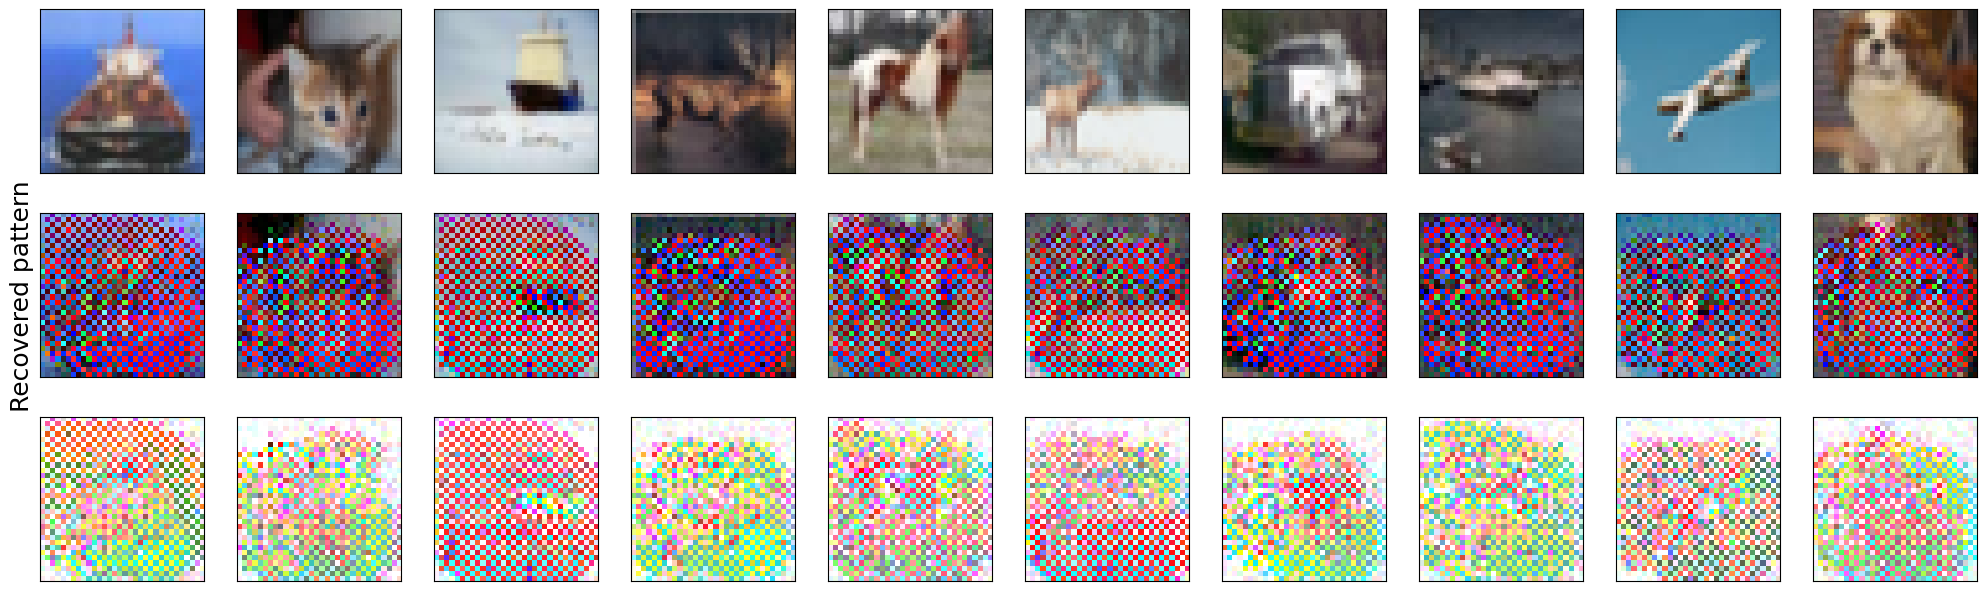

The model is a Trojan model and the target label is: 1


In [7]:
import shutil
import os
os.environ['NOTEBOOK_MODE'] = '1'
import sys
import torch as ch
import numpy as np
import seaborn as sns
from scipy import stats
from tqdm import tqdm, tqdm_notebook
import matplotlib.pyplot as plt
from robustness import model_utils
from robustness.tools.vis_tools import show_image_row, show_image_column
#from robustness.tools.constants import CLASS_DICT
#from user_constants import DATA_PATH_DICT
from dataset_registry import get_dataset_spec

# Change only these two values when switching model/dataset
DATASET_NAME = 'cifar10'  # 'cifar10' or 'gtsrb'
MODEL_PATH = './models/cifar_high_asr.pt'

dataset_spec = get_dataset_spec(DATASET_NAME)
data_path = dataset_spec.name
robustness_dataset = dataset_spec.make_robustness_dataset(data_path)

#read data
#If you want to use other imgs instead of the given samples, then do not comment the following line out
#ds = wrapper()
%matplotlib inline


# Load model

model_kwargs = {
    'arch': 'resnet50',
    'dataset': robustness_dataset,
    'resume_path': MODEL_PATH
}

model_kwargs['state_dict_path'] = 'model'
model, _ = model_utils.make_and_restore_model(**model_kwargs)
model.eval()
pass

# CIFAR keeps the original latent objective; GTSRB uses a target-class margin.
def activation_loss(mod, inp, targ):
    logits, rep = mod(inp, with_latent=True, fake_relu=True)
    if dataset_spec.name == 'cifar10':
        return rep, None
    target_class = int(targ)
    competing_logits = logits.clone()
    competing_logits[:, target_class] = -ch.inf
    margin = logits[:, target_class] - competing_logits.max(1).values
    return margin.unsqueeze(1), None

#If you want to use other imgs instead of the given samples, then use choice1
#choice1: clean validation input
# x_batch, y_batch = ds.eval_data.get_next_batch(10,
#                                                          multiple_passes=True)
# x_batch = x_batch / 255.0
# im = ch.from_numpy(x_batch.astype(np.float32).transpose((0, 3, 1, 2))).cuda()


#choice2: using the given img samples
if dataset_spec.name == 'cifar10':
    # Keep the original CIFAR-10 detector seeds.
    im = ch.load('cifarimg.pt', map_location='cpu')
else:
    # GTSRB has no bundled seed tensor, so use ten clean test images.
    seed_dataset = dataset_spec.make_torchvision_dataset(
        root=data_path, train=False, transform=dataset_spec.test_transform(), download=False
    )
    im = ch.stack([seed_dataset[index][0] for index in range(10)])
im = im.float().cuda()

#If you want to use noise inputs instead of the given samples, then use choice3
#If you use noise inputs, please comment out the related lines in vis_tool.py for better visualization
#choice3: using random noise input (together with choice 1)
#im = ch.load('cifar10noise.pt')


if dataset_spec.name == 'cifar10':
    # Preserve the original CIFAR-10 DFTND detector.
    for gamma_power in range(3, 4):
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 1000, 'targeted': False,
            'gamma': 0.000001 * (10 ** gamma_power),
        }
        output_rec, im_feat = model(im, 0, make_adv=True, fake_relu=True, **kwargs)
        output_ori, _ = model(im, 0, make_adv=False)
        log_increase = ch.mean(output_rec - output_ori, 0)
        print('Class scores:', log_increase)
        show_image_row([im_feat.detach().cpu()], ['Recovered pattern'], fontsize=18, baseline=[im.cpu()])

        T = 100.0  # Original CIFAR-10 threshold
        detected = ch.where(log_increase > T)[0].tolist()
        if detected:
            for target in detected:
                print(f'The model is a Trojan model and the target label is: {target}')
        else:
            print('The model is a clean model')
else:
    # GTSRB: recover a sparse universal pattern separately for each output class.
    with ch.no_grad():
        output_ori, _ = model(im, 0, make_adv=False)

    class_scores = []
    best_images = None
    best_score = -float('inf')
    for target_class in range(dataset_spec.num_classes):
        # Use the same initialization for every class so scores are comparable.
        ch.manual_seed(1234)
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 100, 'targeted': False, 'gamma': 0.01,
            'mask_start': 0.05, 'random_pattern': True,
        }
        output_rec, candidate_images = model(
            im, target_class, make_adv=True, fake_relu=True, **kwargs
        )
        success_rate = (output_rec.argmax(1) == target_class).float().mean()
        target_increase = (
            output_rec[:, target_class] - output_ori[:, target_class]
        ).mean()
        score = success_rate * ch.clamp(target_increase, min=0)
        class_scores.append(score.detach())
        if score.item() > best_score:
            best_score = score.item()
            best_images = candidate_images.detach()
        print(
            f'class {target_class:2d}: score={score.item():.3f}, '
            f'success={success_rate.item():.0%}, increase={target_increase.item():.3f}'
        )

    class_scores = ch.stack(class_scores)
    target = int(class_scores.argmax().item())
    print('Class scores:', class_scores)
    show_image_row([best_images.cpu()], ['Best recovered pattern'], fontsize=18, baseline=[im.cpu()])

    T = 20.0  # Calibrated using the provided clean/high-ASR GTSRB checkpoints
    if class_scores[target].item() > T:
        print(f'The model is a Trojan model and the target label is: {target}')
    else:
        print('The model is a clean model')


=> loading checkpoint './models/cifar_low_asr.pt'
=> loaded checkpoint './models/cifar_low_asr.pt' (epoch 27)
Class scores: tensor([ 36.4270,  40.6087,  68.4276, -18.3644, -70.7779,  56.0230,  24.9031,
        -32.4726, -44.8326, -60.9407], device='cuda:0',
       grad_fn=<MeanBackward1>)


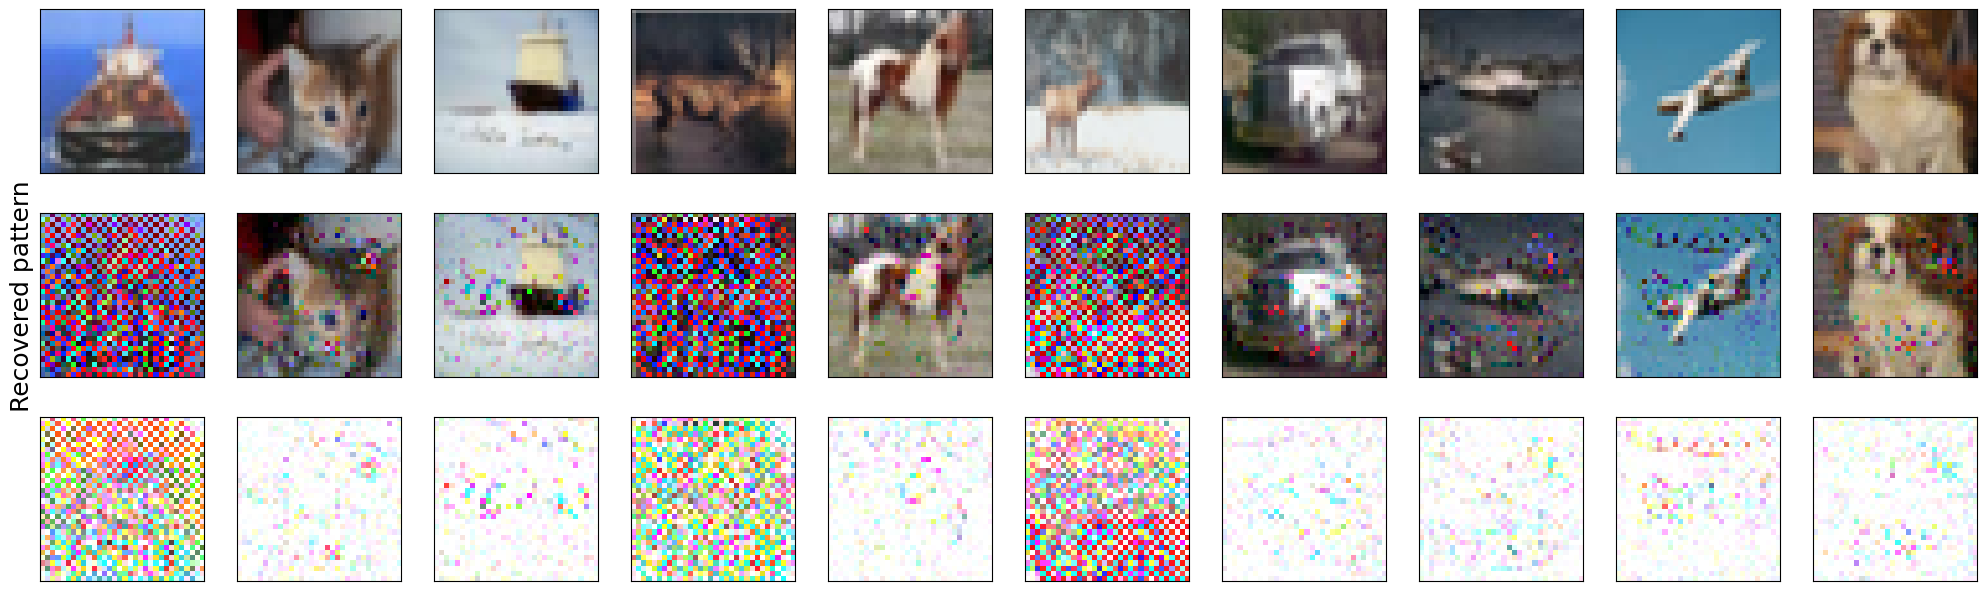

The model is a clean model


In [8]:
import shutil
import os
os.environ['NOTEBOOK_MODE'] = '1'
import sys
import torch as ch
import numpy as np
import seaborn as sns
from scipy import stats
from tqdm import tqdm, tqdm_notebook
import matplotlib.pyplot as plt
from robustness import model_utils
from robustness.tools.vis_tools import show_image_row, show_image_column
#from robustness.tools.constants import CLASS_DICT
#from user_constants import DATA_PATH_DICT
from dataset_registry import get_dataset_spec

# Change only these two values when switching model/dataset
DATASET_NAME = 'cifar10'  # 'cifar10' or 'gtsrb'
MODEL_PATH = './models/cifar_low_asr.pt'

dataset_spec = get_dataset_spec(DATASET_NAME)
data_path = dataset_spec.name
robustness_dataset = dataset_spec.make_robustness_dataset(data_path)

#read data
#If you want to use other imgs instead of the given samples, then do not comment the following line out
#ds = wrapper()
%matplotlib inline


# Load model

model_kwargs = {
    'arch': 'resnet50',
    'dataset': robustness_dataset,
    'resume_path': MODEL_PATH
}

model_kwargs['state_dict_path'] = 'model'
model, _ = model_utils.make_and_restore_model(**model_kwargs)
model.eval()
pass

# CIFAR keeps the original latent objective; GTSRB uses a target-class margin.
def activation_loss(mod, inp, targ):
    logits, rep = mod(inp, with_latent=True, fake_relu=True)
    if dataset_spec.name == 'cifar10':
        return rep, None
    target_class = int(targ)
    competing_logits = logits.clone()
    competing_logits[:, target_class] = -ch.inf
    margin = logits[:, target_class] - competing_logits.max(1).values
    return margin.unsqueeze(1), None

#If you want to use other imgs instead of the given samples, then use choice1
#choice1: clean validation input
# x_batch, y_batch = ds.eval_data.get_next_batch(10,
#                                                          multiple_passes=True)
# x_batch = x_batch / 255.0
# im = ch.from_numpy(x_batch.astype(np.float32).transpose((0, 3, 1, 2))).cuda()


#choice2: using the given img samples
if dataset_spec.name == 'cifar10':
    # Keep the original CIFAR-10 detector seeds.
    im = ch.load('cifarimg.pt', map_location='cpu')
else:
    # GTSRB has no bundled seed tensor, so use ten clean test images.
    seed_dataset = dataset_spec.make_torchvision_dataset(
        root=data_path, train=False, transform=dataset_spec.test_transform(), download=False
    )
    im = ch.stack([seed_dataset[index][0] for index in range(10)])
im = im.float().cuda()

#If you want to use noise inputs instead of the given samples, then use choice3
#If you use noise inputs, please comment out the related lines in vis_tool.py for better visualization
#choice3: using random noise input (together with choice 1)
#im = ch.load('cifar10noise.pt')


if dataset_spec.name == 'cifar10':
    # Preserve the original CIFAR-10 DFTND detector.
    for gamma_power in range(3, 4):
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 1000, 'targeted': False,
            'gamma': 0.000001 * (10 ** gamma_power),
        }
        output_rec, im_feat = model(im, 0, make_adv=True, fake_relu=True, **kwargs)
        output_ori, _ = model(im, 0, make_adv=False)
        log_increase = ch.mean(output_rec - output_ori, 0)
        print('Class scores:', log_increase)
        show_image_row([im_feat.detach().cpu()], ['Recovered pattern'], fontsize=18, baseline=[im.cpu()])

        T = 100.0  # Original CIFAR-10 threshold
        detected = ch.where(log_increase > T)[0].tolist()
        if detected:
            for target in detected:
                print(f'The model is a Trojan model and the target label is: {target}')
        else:
            print('The model is a clean model')
else:
    # GTSRB: recover a sparse universal pattern separately for each output class.
    with ch.no_grad():
        output_ori, _ = model(im, 0, make_adv=False)

    class_scores = []
    best_images = None
    best_score = -float('inf')
    for target_class in range(dataset_spec.num_classes):
        # Use the same initialization for every class so scores are comparable.
        ch.manual_seed(1234)
        kwargs = {
            'criterion': ch.nn.CrossEntropyLoss(),
            'custom_loss': activation_loss,
            'constraint': 'inf', 'eps': 1, 'step_size': 0.1,
            'iterations': 100, 'targeted': False, 'gamma': 0.01,
            'mask_start': 0.05, 'random_pattern': True,
        }
        output_rec, candidate_images = model(
            im, target_class, make_adv=True, fake_relu=True, **kwargs
        )
        success_rate = (output_rec.argmax(1) == target_class).float().mean()
        target_increase = (
            output_rec[:, target_class] - output_ori[:, target_class]
        ).mean()
        score = success_rate * ch.clamp(target_increase, min=0)
        class_scores.append(score.detach())
        if score.item() > best_score:
            best_score = score.item()
            best_images = candidate_images.detach()
        print(
            f'class {target_class:2d}: score={score.item():.3f}, '
            f'success={success_rate.item():.0%}, increase={target_increase.item():.3f}'
        )

    class_scores = ch.stack(class_scores)
    target = int(class_scores.argmax().item())
    print('Class scores:', class_scores)
    show_image_row([best_images.cpu()], ['Best recovered pattern'], fontsize=18, baseline=[im.cpu()])

    T = 20.0  # Calibrated using the provided clean/high-ASR GTSRB checkpoints
    if class_scores[target].item() > T:
        print(f'The model is a Trojan model and the target label is: {target}')
    else:
        print('The model is a clean model')
